In [1]:
# Importing necessary libraries
import pandas as pd
import csv
import numpy as np

In [2]:
# STEP 1: Map each of the 3 columns (admission_type_id, discharge_disposition_id, admission_source_id) to their textual descriptions in diabetic_data.csv
#---------------------------------------------------------------------------------------------------------------------------------------------------------

# 1. Load the main diabetic dataset (using the data/ folder path)
df = pd.read_csv('../data/raw/diabetic_data.csv')

# 2. Parse the IDS_mapping.csv file into separate dictionaries
admission_type_map = {}
discharge_disposition_map = {}
admission_source_map = {}
current_map = None

# 3. Make sure to also read the IDS mapping file from the data/ folder!
with open('../data/raw/IDS_mapping.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        # Skip empty rows
        if not row or row == ['', '']:
            continue
        
        # Check which section we are currently reading
        if 'admission_type_id' in row[0]:
            current_map = admission_type_map
            continue
        elif 'discharge_disposition_id' in row[0]:
            current_map = discharge_disposition_map
            continue
        elif 'admission_source_id' in row[0]:
            current_map = admission_source_map
            continue
        
        # Add the numeric ID and description text to the active dictionary
        if current_map is not None:
            key = int(row[0].strip())
            val = row[1].strip()
            current_map[key] = val

# 4. Replace the numeric IDs in the 3 columns with their textual descriptions
df['admission_type_id'] = df['admission_type_id'].map(admission_type_map)
df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_disposition_map)
df['admission_source_id'] = df['admission_source_id'].map(admission_source_map)


# 5. Without preloaded folder setup, uncomment the line below to save the updated dataset to a new CSV file (this will save in your main project folder)
df.to_csv('../data/processed/diabetic_data_mapped.csv', index=False)




In [3]:

# STEP 2: General Cleaning
#---------------------------------------------------------------------------------------------------------------------------------------------------------
diabetic_data_mapped = pd.read_csv('../data/processed/diabetic_data_mapped.csv')


# ─────────────────────────────────────────────────────────────────────────────
# Drop pure identifiers
# ─────────────────────────────────────────────────────────────────────────────
# encounter_id: unique per row, no clinical meaning, cannot be a feature
diabetic_data_mapped = diabetic_data_mapped.drop(columns=['encounter_id'])


# ─────────────────────────────────────────────────────────────────────────────
# Deduplicate: one row per patient (keep first encounter only)
# ─────────────────────────────────────────────────────────────────────────────
# Why: 16,773 patients have 2–40 encounters each. If a patient's later
# encounter is in our training set and an earlier one is in our test set,
# the model learns patterns specific to that individual — not the population.
# Standard practice: keep the *first* encounter per patient (lowest encounter_id
# is a reliable proxy for chronological order in this dataset since IDs are
# assigned sequentially).
diabetic_data_mapped = diabetic_data_mapped.sort_values('patient_nbr')          # consistent ordering
diabetic_data_mapped = diabetic_data_mapped.drop_duplicates(subset='patient_nbr', keep='first')
diabetic_data_mapped = diabetic_data_mapped.drop(columns=['patient_nbr'])       # now safe to remove



# ─────────────────────────────────────────────────────────────────────────────
# Drop catastrophic missing columns (>94% missing)
# ─────────────────────────────────────────────────────────────────────────────
# weight:        96.9% '?' placeholders. Imputing ~98K/101K rows manufactures
#                data. Any signal would come from the 3% with real values —
#                too sparse to generalise.
# max_glu_serum: 94.7% NaN. Recorded only in the most acute cases, so its
#                presence encodes severity confound, not glucose level per se.
#                Dropping avoids misleading the model.
diabetic_data_mapped = diabetic_data_mapped.drop(columns=['weight', 'max_glu_serum'])



# ─────────────────────────────────────────────────────────────────────────────
#Drop high-missing / low-signal columns
# ─────────────────────────────────────────────────────────────────────────────
# payer_code:       39.6% '?'. Encodes insurer type, not clinical risk.
#                   Would require 40% imputation before encoding — noisy and
#                   not actionable for a care team doing pre-discharge
#                   intervention.
# medical_specialty: 49.1% '?'. Admitting specialty is weakly proxied by
#                   diag_1/2/3 already. An "Unknown" bucket for half the data
#                   dilutes whatever signal remains.
# A1Cresult:        83.3% NaN. Only ordered in severe/uncertain cases, so
#                   missingness correlates with severity — the column encodes
#                   "was tested" more than "what the result was". Dropped here;
#                   if you want to use it, engineer a binary A1C_tested flag
#                   and impute/bucket the result separately.
diabetic_data_mapped = diabetic_data_mapped.drop(columns=['payer_code', 'medical_specialty', 'A1Cresult'])



# ─────────────────────────────────────────────────────────────────────────────
# Drop near-zero variance drug columns
# ─────────────────────────────────────────────────────────────────────────────
# Every column below is 'No' for 99.96–100% of patients. A one-hot encoded
# column that is 1 for fewer than ~40 rows out of 71K cannot split any
# meaningful decision boundary — it just adds noise.
#   examide, citoglipton          → literally zero non-No values (constant)
#   acetohexamide, troglitazone,
#   glimepiride-pioglitazone,
#   metformin-rosiglitazone,
#   metformin-pioglitazone        → 1–3 non-No values across entire dataset
#   glipizide-metformin           → 13 non-No values
#   tolbutamide                   → 23 non-No values
#   miglitol                      → 38 non-No values
#   tolazamide                    → 39 non-No values
zero_var_drugs = [
    'examide', 'citoglipton', 'acetohexamide', 'troglitazone',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'glipizide-metformin',
    'tolbutamide', 'miglitol', 'tolazamide'
]
diabetic_data_mapped = diabetic_data_mapped.drop(columns=zero_var_drugs)



# ─────────────────────────────────────────────────────────────────────────────
# Filter out non-readmittable discharge dispositions
# ─────────────────────────────────────────────────────────────────────────────
# Patients discharged to hospice or recorded as expired cannot physically be
# readmitted within 30 days. Keeping them artificially inflates the NO class
# and biases the model toward under-predicting readmission risk.
# We filter these rows out entirely — they are not a valid population for
# this prediction task.
#
# The three "Expired" variants and two "Hospice" variants are confirmed from
# the actual value_counts() of this dataset. "Not Mapped" is excluded from
# this filter — unknown disposition is not the same as confirmed non-survival.
non_readmittable = [
    'Expired',
    'Expired at home. Medicaid only, hospice.',
    'Expired in a medical facility. Medicaid only, hospice.',
    'Hospice / home',
    'Hospice / medical facility',
]
 
rows_before = len(diabetic_data_mapped)
diabetic_data_mapped = diabetic_data_mapped[~diabetic_data_mapped['discharge_disposition_id'].isin(non_readmittable)]
rows_removed = rows_before - len(diabetic_data_mapped)





# ─────────────────────────────────────────────────────────────────────────────
# Binary encode the target variable
# ─────────────────────────────────────────────────────────────────────────────
# Original values: '<30', '>30', 'NO'
# Task is 30-day readmission, so:
#   '<30' → 1  (readmitted within 30 days — the positive class)
#   '>30' → 0  (readmitted after 30 days is NOT a 30-day readmission)
#   'NO'  → 0  (not readmitted at all)
diabetic_data_mapped['readmitted'] = (diabetic_data_mapped['readmitted'] == '<30').astype(int)
 
print(f"\nTarget distribution after binary encoding:")
print(diabetic_data_mapped['readmitted'].value_counts())
print(f"30-day readmission rate: {diabetic_data_mapped['readmitted'].mean():.1%}")




# ─────────────────────────────────────────────────────────────────────────────
# FINAL STATE
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nFinal shape: {diabetic_data_mapped.shape}")
print(f"Remaining columns:\n{list(diabetic_data_mapped.columns)}")
 
 #  Without preloaded folder setup, uncomment the line below to save the cleaned dataset to a new CSV file (this will save in your main project folder)
diabetic_data_mapped.to_csv('../data/processed/diabetic_data_cleaned.csv', index=False)




Target distribution after binary encoding:
readmitted
0    64606
1     5055
Name: count, dtype: int64
30-day readmission rate: 7.3%

Final shape: (69661, 32)
Remaining columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'readmitted']


In [4]:

# STEP 3: Standardize nulls
#---------------------------------------------------------------------------------------------------------------------------------------------------------
temp_diabetic_data_cleaned = pd.read_csv('../data/processed/diabetic_data_cleaned.csv')


# ─────────────────────────────────────────────────────────────────────────────
# Deal with null values
# ─────────────────────────────────────────-──────────────────


temp_diabetic_data_cleaned['admission_source_id'].unique() # need to standardize 'nan', 'Not Mapped', and 'Not Available' to 'NaN' 
temp_diabetic_data_cleaned['admission_type_id'].unique() # need to standardize 'nan', 'Not Mapped', and 'Not Available' to 'NaN' 
temp_diabetic_data_cleaned['discharge_disposition_id'].unique()  # need to standardize 'nan' and 'Not Mapped' to 'NaN' 
# Solution: Replace with proper NaN null values in admission columns
admission_cols = ['admission_source_id', 'admission_type_id']
temp_diabetic_data_cleaned[admission_cols] = temp_diabetic_data_cleaned[admission_cols].replace(
    [np.nan, 'Not Mapped', 'Not Available'], "Unknown"
)
# Replace with proper NaN null values in discharge column
temp_diabetic_data_cleaned['discharge_disposition_id'] = temp_diabetic_data_cleaned['discharge_disposition_id'].replace(
    [np.nan, 'Not Mapped'], "Unknown"
)


temp_diabetic_data_cleaned['race'].unique() # need to standardize '?', to 'NaN' 
temp_diabetic_data_cleaned['diag_3'].unique() # need to standardize '?', to 'NaN' 
temp_diabetic_data_cleaned['diag_2'].unique() # need to standardize '?', to 'NaN' 
temp_diabetic_data_cleaned['diag_1'].unique() # need to standardize '?', to 'NaN' 
# Solution: Replace '?' with NaN values
cols_to_standardize = ['race', 'diag_1', 'diag_2', 'diag_3']
temp_diabetic_data_cleaned[cols_to_standardize] = temp_diabetic_data_cleaned[cols_to_standardize].replace('?', "Unknown")



temp_diabetic_data_cleaned['gender'].unique() # need to standardize 'Unknown/Invalid' to 'NaN'
# Solution: Replace 'Unknown/Invalid' with np.nan in the gender column
temp_diabetic_data_cleaned['gender'] = temp_diabetic_data_cleaned['gender'].replace('Unknown/Invalid', "Unknown")



── Outlier summary (Tukey 1.5×IQR fences) ──────────────────────────
                    min    Q1  median    Q3    max   IQR  lower_fence  upper_fence  n_outliers  pct_outliers
time_in_hospital    1.0   2.0     3.0   6.0   14.0   4.0         -4.0         12.0      1423.0          2.04
num_lab_procedures  1.0  31.0    44.0  57.0  132.0  26.0         -8.0         96.0        99.0          0.14
num_procedures      0.0   0.0     1.0   2.0    6.0   2.0         -3.0          5.0      3693.0          5.30
num_medications     1.0  10.0    14.0  20.0   81.0  10.0         -5.0         35.0      1859.0          2.67
number_outpatient   0.0   0.0     0.0   0.0   38.0   0.0          0.0          0.0      9721.0         13.95
number_emergency    0.0   0.0     0.0   0.0   42.0   0.0          0.0          0.0      5731.0          8.23
number_inpatient    0.0   0.0     0.0   0.0   19.0   0.0          0.0          0.0     14700.0         21.10
number_diagnoses    1.0   6.0     8.0   9.0   16.0   3.0  

/var/folders/6y/f0z2lls53kb2dt1zq9lsw6jr0000gn/T/ipykernel_91671/1494662604.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/6y/f0z2lls53kb2dt1zq9lsw6jr0000gn/T/ipykernel_91671/1494662604.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/6y/f0z2lls53kb2dt1zq9lsw6jr0000gn/T/ipykernel_91671/1494662604.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/6y/f0z2lls53kb2dt1zq9lsw6jr0000gn/T/ipykernel_91671/1494662604.py:68: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horiz

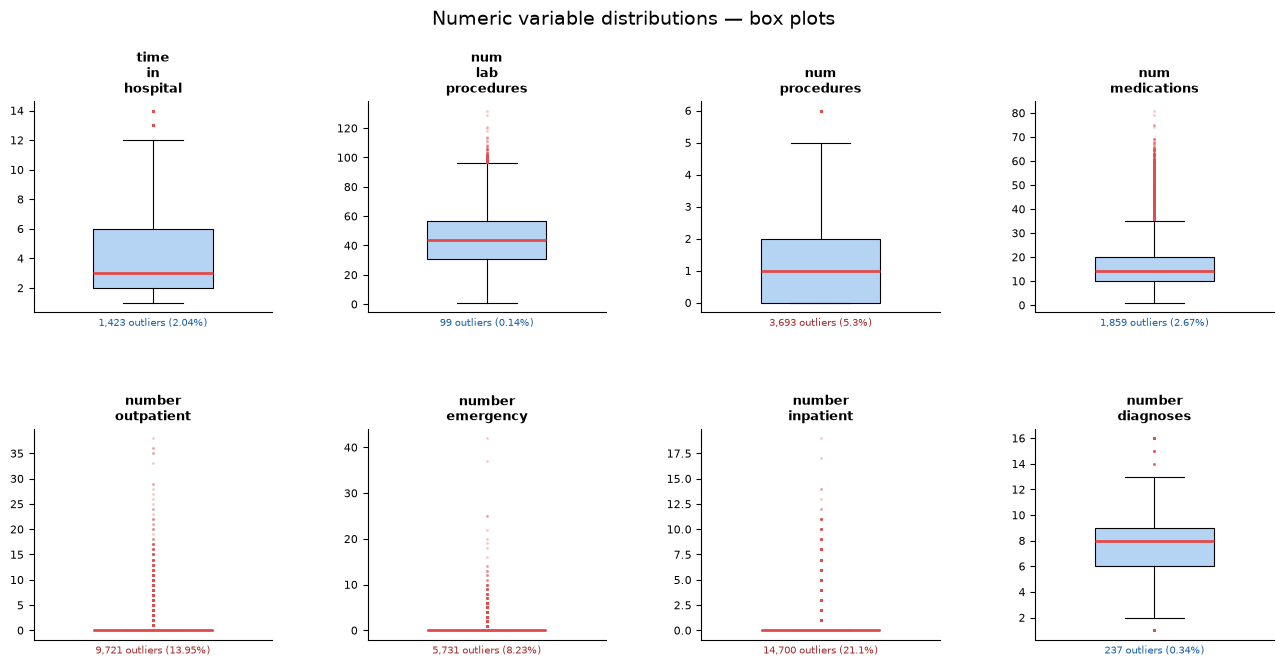

In [5]:
# STEP 4: Check for outliers in numeric data
#---------------------------------------------------------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Load data ──────────────────────────────────────────────────────────────
temp_diabetic_data_cleaned

# Exclude binary/target columns — adjust this list as needed
EXCLUDE = {"readmitted"}
num_cols = [c for c in temp_diabetic_data_cleaned.select_dtypes(include="number").columns if c not in EXCLUDE]

# ── 2. IQR outlier summary table ─────────────────────────────────────────────
def iqr_summary(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR      # standard Tukey fence
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return pd.Series({
        "min":           series.min(),
        "Q1":            Q1,
        "median":        series.median(),
        "Q3":            Q3,
        "max":           series.max(),
        "IQR":           IQR,
        "lower_fence":   lower,
        "upper_fence":   upper,
        "n_outliers":    len(outliers),
        "pct_outliers":  round(len(outliers) / len(series) * 100, 2),
    })

summary = temp_diabetic_data_cleaned[num_cols].apply(iqr_summary).T
summary[["min","Q1","median","Q3","max","IQR","lower_fence","upper_fence"]] = \
    summary[["min","Q1","median","Q3","max","IQR","lower_fence","upper_fence"]].round(2)

print("\n── Outlier summary (Tukey 1.5×IQR fences) ──────────────────────────")
print(summary.to_string())
print()

# Flag columns with >5% outliers
flagged = summary[summary["pct_outliers"] > 5]
if not flagged.empty:
    print("⚠  Columns with >5% outliers:")
    for col, row in flagged.iterrows():
        print(f"   {col:30s}  {row['n_outliers']:>6,.0f} rows  ({row['pct_outliers']}%)"
              f"  fence=[{row['lower_fence']}, {row['upper_fence']}]")
else:
    print("✓  No columns exceed 5% outliers.")
print()

# ── 3. Box plot grid ──────────────────────────────────────────────────────────
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols          # ceiling division

fig = plt.figure(figsize=(ncols * 4, nrows * 3.5))
fig.suptitle("Numeric variable distributions — box plots", fontsize=14, y=1.01)

gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.55, wspace=0.4)

for i, col in enumerate(num_cols):
    ax = fig.add_subplot(gs[i // ncols, i % ncols])
    data = temp_diabetic_data_cleaned[col].dropna()

    # Box plot
    bp = ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="#E24B4A", linewidth=2),   # red median line
        boxprops=dict(facecolor="#B5D4F4", linewidth=0.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markersize=2, alpha=0.3,
                        markerfacecolor="#E24B4A", markeredgewidth=0),
    )

    # Annotate outlier count
    row = summary.loc[col]
    n_out = int(row["n_outliers"])
    pct   = row["pct_outliers"]
    color = "#A32D2D" if pct > 5 else "#185FA5" if pct > 0 else "#3B6D11"
    ax.set_title(col.replace("_", "\n"), fontsize=9, fontweight="bold", pad=6)
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    label = f"{n_out:,} outliers ({pct}%)" if n_out else "no outliers"
    ax.set_xlabel(label, fontsize=7.5, color=color, labelpad=4)

# Hide unused subplot slots
for j in range(i + 1, nrows * ncols):
    fig.add_subplot(gs[j // ncols, j % ncols]).set_visible(False)

 # Without preloaded folder setup, uncomment the line below to save the boxplot grid to a PNG file (this will save in your main project folder)
plt.savefig("../reports/outlier_boxplots.png", dpi=150, bbox_inches="tight")






# Solution: Dealing with outliers
#---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# NUMERIC VARIABLES:

# time_in_hospital --> No action needed! The 1–14 range is bounded and meaningful.

# num_lab_procedures --> No action needed! This column will work well as-is in any model.

# num_procedures --> Cap at 5! Cap (Winsorize) at 5. This collapses the artificial spike at 6 into the next valid value, which is defensible since 6 likely represents "6 or more" anyway.
cap = 5
temp_diabetic_data_cleaned['num_procedures'] = temp_diabetic_data_cleaned['num_procedures'].clip(upper=cap)

# num_medications --> Cap at the 99th percentile. This preserves the real variability in the bulk of the data while neutralising the implausible extreme values without deleting any rows.
p99 = temp_diabetic_data_cleaned['num_medications'].quantile(0.99)
temp_diabetic_data_cleaned['num_medications'] = temp_diabetic_data_cleaned['num_medications'].clip(upper=p99)

# number_outpatient --> Bin into 3 ordered categories. This captures the meaningful clinical distinction (never visited / occasionally / frequently) without the zero-inflation distorting your model.
def bin_visits(x):
    if x == 0:   return 0  # no visits
    elif x <= 2: return 1  # low
    else:        return 2  # high
temp_diabetic_data_cleaned['number_outpatient_cat'] = temp_diabetic_data_cleaned['number_outpatient'].map(bin_visits)
# 0=none, 1=low(1-2), 2=high(3+)

# number_emergency --> Bin into 3 categories, same logic as outpatient. The 42-visit extreme value is automatically neutralised by binning — it just becomes "high", same as 5.
def bin_emergency(x):
    if x == 0:   return 0  # none
    elif x <= 1: return 1  # low
    else:        return 2  # high
temp_diabetic_data_cleaned['number_emergency_cat'] = temp_diabetic_data_cleaned['number_emergency'].map(bin_emergency)
# Tighter bins because p99 is only 2

# number_inpatient --> Bin into 4 ordered categories to preservejvnjm the risk gradient while eliminating zero-inflation and the extreme tail.
def bin_inpatient(x):
    if x == 0:   return 0  # none
    elif x == 1: return 1  # one prior
    elif x <= 3: return 2  # 2–3 prior
    else:        return 3  # 4+ prior

temp_diabetic_data_cleaned['number_inpatient_cat'] = temp_diabetic_data_cleaned['number_inpatient'].map(bin_inpatient)
# 4 bins capture the readmission risk gradient

# number_diagnoses --> No action needed! The 1–16 range is bounded and meaningful. Keep outliers (14–16) untouched — they're a tiny 0.34% and clinically plausible.,z





In [ ]:
# STEP 4: Last updates before export to PowerBI
#---------------------------------------------------------------------------------------------------------------------------------------------------------

# 1. Add age_midpoint numeric column
temp_diabetic_data_cleaned['age_midpoint'] = temp_diabetic_data_cleaned['age'].str.extract(r'\[(\d+)').astype(int) + 5

# 2. Rename glyburide-metformin
temp_diabetic_data_cleaned = temp_diabetic_data_cleaned.rename(columns={'glyburide-metformin': 'glyburide_metformin'})



# Without preloaded folder setup, uncomment the line below to save the cleaned dataset to a new CSV file (this will save in your main project folder)
temp_diabetic_data_cleaned.to_csv('../data/processed/Final_Diabetic_Data.csv', index=False)